# MZI Delay Arm -- Dense delta_L_um Sweep (Library Densification)

This notebook does **not** modify `03_mzi_arm.ipynb`. It extends that notebook's own
`delta_L_um` sweep (`{14.0, 15.0, 17.5, 20.0, 25.0, 30.0}`, radius_um=5.0, euler bends)
to an even 2um grid from the geometry's feasible floor (~13.27um) up to 34um, for use
by `pic_toolkit.optimization.arm_library`'s length-axis S-parameter interpolation
(needed for the MUX2 stage-1 adjoint optimization -- see
`docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section; that optimization effort is now paused).

New points only -- values already covered by the existing sweep (14, 20, 30) are not
re-simulated. Saved to a **new sibling directory**,
`data/sparams/mzi_arm/sweep_dense2um/`, so the original `sweep/` directory's
provenance stays untouched (same precedent as `sweep_r2.5/`, a separate-provenance
batch at a different bend radius).

**Do not use "Run All."** Each point is a full 2-direction FDTD simulation at
resolution=40; on this machine's limited RAM, run cells one at a time and expect the
full 8-point sweep to take a long time (this repo's own `CLAUDE.md` notes a full
`simulate_baseline()` + sweep "can take hours").

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pic_toolkit.meep_sim import mzi_arm
from pic_toolkit import sparams, sweep, style

style.apply_style()
%matplotlib inline

params = dict(mzi_arm.DEFAULT_PARAMS)  # same working copy convention as 03_mzi_arm.ipynb
params


{'wg_width_um': 0.5,
 'core_index': 2.7,
 'clad_index': 1.44,
 'polarization': 'TE',
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'resolution': 40,
 'dpml_um': 1.0,
 'radius_um': 5.0,
 'bend_type': 'euler',
 'extra_straight_um': 0.864,
 'lead_len_um': 3.0,
 'n_freq': 21,
 'margin_um': 1.5,
 'port_offset_um': 1.0,
 'source_offset_um': 0.5}

## New target grid

`extra_straight_um_for_delta_L` converts each target `delta_L_um` to this geometry's
own swept parameter (`extra_straight_um`), raising `ValueError` if a target is below
the floor (~13.27um at `radius_um=5.0`, `bend_type="euler"`) -- none of these targets
are.

In [2]:
EXISTING_DELTA_L_UM = [14.0, 15.0, 17.5, 20.0, 25.0, 30.0]  # already in data/sparams/mzi_arm/sweep/
NEW_DELTA_L_UM = [16.0, 18.0, 22.0, 24.0, 26.0, 28.0, 32.0, 34.0]  # this notebook's own new points

NEW_EXTRA_STRAIGHT_UM = [mzi_arm.extra_straight_um_for_delta_L(dl, params) for dl in NEW_DELTA_L_UM]
print(list(zip(NEW_DELTA_L_UM, [round(e, 4) for e in NEW_EXTRA_STRAIGHT_UM])))


[(16.0, 1.364), (18.0, 2.364), (22.0, 4.364), (24.0, 5.364), (26.0, 6.364), (28.0, 7.364), (32.0, 9.364), (34.0, 10.364)]


## Run the sweep

Same loose sweep tolerances `03_mzi_arm.ipynb` uses (this is the same geometry family,
just denser sampling) -- `sweep.grid_sweep` saves one artifact per point as it
completes, so an interrupted run loses no already-finished points.

> **STOP -- this cell runs real FDTD simulations (8 points, each a 2-direction
> resolution=40 run). Expect a long runtime. Run it, then wait.**

In [3]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.15, reciprocity_tol=0.15, passivity_tol=0.05, max_loss_fraction=0.30)

sweep_rows = sweep.grid_sweep(
    simulate_fn=mzi_arm.simulate_baseline,
    base_params=params,
    param_grid={"extra_straight_um": NEW_EXTRA_STRAIGHT_UM},
    artifact_dir=Path("../data/sparams/mzi_arm/sweep_dense2um"),
    component_name="mzi_arm",
    check_kwargs=SWEEP_CHECK_KWARGS,
)
n_passed = sum(row["validation_passed"] for row in sweep_rows)
print(f"dense delta_L sweep: {n_passed}/{len(sweep_rows)} points within the (loose) sweep tolerance")
sweep.save_manifest(sweep_rows, Path("../data/sparams/mzi_arm/sweep_dense2um/manifest.csv"))


[1/8  12%] running mzi_arm (extra_straight_um=1.3640000000000008) ...


[2/8  25%] running mzi_arm (extra_straight_um=2.3640000000000008) ...


[3/8  37%] running mzi_arm (extra_straight_um=4.364000000000001) ...


[4/8  50%] running mzi_arm (extra_straight_um=5.364000000000001) ...


[5/8  62%] running mzi_arm (extra_straight_um=6.364000000000001) ...


[6/8  75%] running mzi_arm (extra_straight_um=7.364000000000001) ...


[7/8  87%] running mzi_arm (extra_straight_um=9.364) ...


[8/8  100%] running mzi_arm (extra_straight_um=10.364) ...


dense delta_L sweep: 8/8 points within the (loose) sweep tolerance


## Visualize: transmission and loss across the combined (existing + new) grid

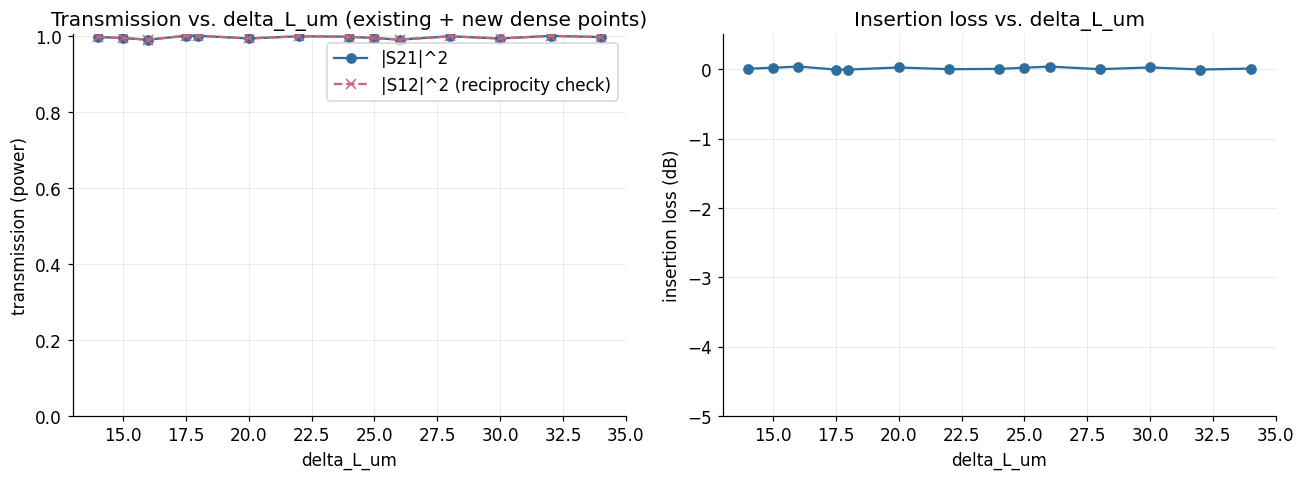

In [4]:
ALL_DELTA_L_UM = sorted(EXISTING_DELTA_L_UM + NEW_DELTA_L_UM)

def _artifact_dir_and_extra(delta_L_um):
    if delta_L_um in EXISTING_DELTA_L_UM:
        return Path("../data/sparams/mzi_arm/sweep"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)
    return Path("../data/sparams/mzi_arm/sweep_dense2um"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)

delta_L_achieved, s21_center, s12_center, loss_db_center = [], [], [], []
for dl_target in ALL_DELTA_L_UM:
    art_dir, extra = _artifact_dir_and_extra(dl_target)
    tag = f"extra_straight{extra}"
    a = sparams.load_artifact(art_dir / f"mzi_arm_{tag}")
    mid = len(a.wavelengths_um) // 2
    s21, s12 = a.s_matrix["21"][mid], a.s_matrix["12"][mid]
    delta_L_achieved.append(mzi_arm.delta_L_um_from_extra(extra, params))
    s21_center.append(np.abs(s21) ** 2)
    s12_center.append(np.abs(s12) ** 2)
    loss_db_center.append(-10 * np.log10(np.abs(s21) ** 2))

delta_L_achieved = np.array(delta_L_achieved)

fig, (ax_t, ax_l) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_t.plot(delta_L_achieved, s21_center, "o-", color=style.COLOR_STEEL, label="|S21|^2")
ax_t.plot(delta_L_achieved, s12_center, "x--", color=style.COLOR_ROSE, label="|S12|^2 (reciprocity check)")
ax_t.set_xlabel("delta_L_um"); ax_t.set_ylabel("transmission (power)")
ax_t.set_title("Transmission vs. delta_L_um (existing + new dense points)")
ax_t.set_ylim(0, 1.005); ax_t.legend()

ax_l.plot(delta_L_achieved, loss_db_center, "o-", color=style.COLOR_STEEL)
ax_l.set_xlabel("delta_L_um"); ax_l.set_ylabel("insertion loss (dB)")
ax_l.set_title("Insertion loss vs. delta_L_um")
ax_l.set_ylim(-5, 0.5)
fig.tight_layout()
plt.show()
